In [1]:
from google.colab import files
uploaded = files.upload()

Saving CoffeeShopSales.xlsx to CoffeeShopSales.xlsx


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [3]:
df = pd.read_excel("CoffeeShopSales.xlsx")

print(df.shape)
df.head()

(149116, 10)


,transaction_id,transaction_date,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_qty   149116 non-null  int64         
 3   store_id          149116 non-null  int64         
 4   store_location    149116 non-null  object        
 5   product_id        149116 non-null  int64         
 6   unit_price        149116 non-null  float64       
 7   product_category  149116 non-null  object        
 8   product_type      149116 non-null  object        
 9   product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(4)
memory usage: 11.4+ MB


In [5]:
df.isnull().sum()

,0
transaction_id,0
transaction_date,0
transaction_qty,0
store_id,0
store_location,0
product_id,0
unit_price,0
product_category,0
product_type,0
product_detail,0


In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.dropna(inplace=True)

In [8]:
print(df.shape)

(149116, 10)


In [9]:
df["ingresos"] = (
    df["transaction_qty"] *
    df["unit_price"]
)

In [10]:
clientes = [
    "Cliente_01",
    "Cliente_02",
    "Cliente_03",
    "Cliente_04",
    "Cliente_05",
    "Cliente_06",
    "Cliente_07",
    "Cliente_08",
    "Cliente_09",
    "Cliente_10",
    "Cliente_11",
    "Cliente_12",
    "Cliente_13",
    "Cliente_14",
    "Cliente_15",
    "Cliente_16",
    "Cliente_17",
    "Cliente_18",
    "Cliente_19",
    "Cliente_20"
]

np.random.seed(42)

df["cliente"] = np.random.choice(
    clientes,
    size=len(df)
)

In [11]:
df[["cliente","product_detail"]].head()

,cliente,product_detail
0,Cliente_07,Ethiopia Rg
1,Cliente_20,Spicy Eye Opener Chai Lg
2,Cliente_15,Dark chocolate Lg
3,Cliente_11,Our Old Time Diner Blend Sm
4,Cliente_08,Spicy Eye Opener Chai Lg


In [12]:
productos_vendidos = (
    df.groupby("product_detail")["transaction_qty"]
      .sum()
      .sort_values(ascending=False)
)

productos_vendidos.head(10)

,transaction_qty
product_detail,
Earl Grey Rg,4708
Dark chocolate Lg,4668
Morning Sunrise Chai Rg,4643
Latte,4602
Peppermint Rg,4564
Columbian Medium Roast Rg,4547
Traditional Blend Chai Rg,4512
Latte Rg,4497
Our Old Time Diner Blend Sm,4484


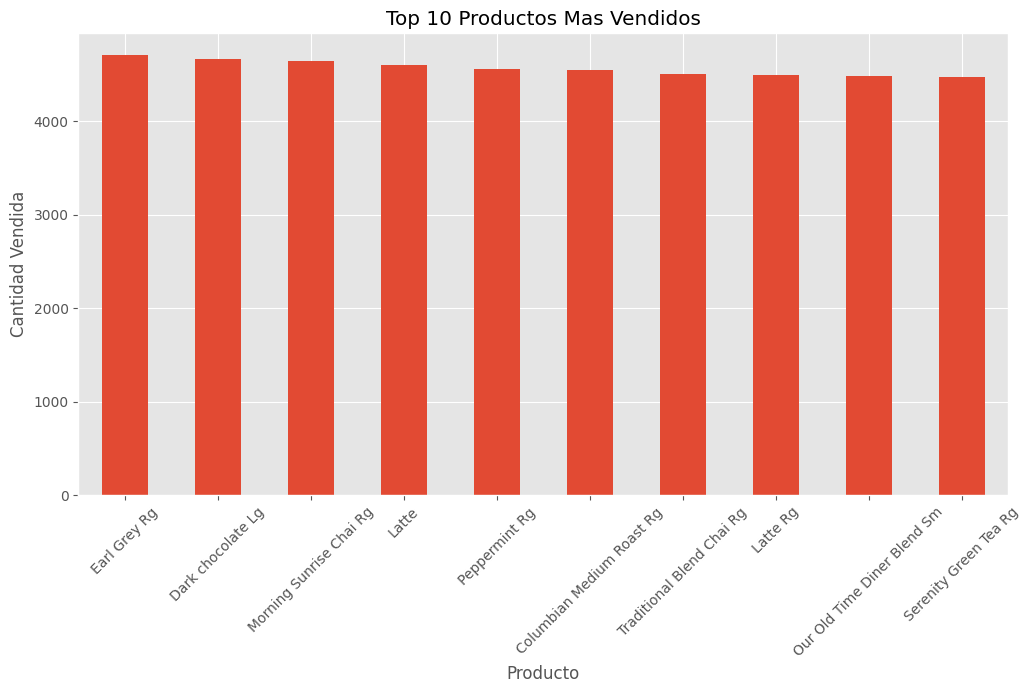

In [23]:
plt.figure(figsize=(12,6))

productos_vendidos.head(10).plot(
    kind="bar"
)

plt.title("Top 10 Productos Mas Vendidos")
plt.xlabel("Producto")
plt.ylabel("Cantidad Vendida")
plt.xticks(rotation=45)

plt.show()

In [14]:
df["transaction_date"] = pd.to_datetime(
    df["transaction_date"]
)

In [15]:
ventas_dia = (
    df.groupby("transaction_date")["ingresos"]
      .sum()
)

In [16]:
ventas_dia.head()

,ingresos
transaction_date,
2023-01-01,2508.20
2023-01-02,2403.35
2023-01-03,2565.00
2023-01-04,2220.10
2023-01-05,2418.85


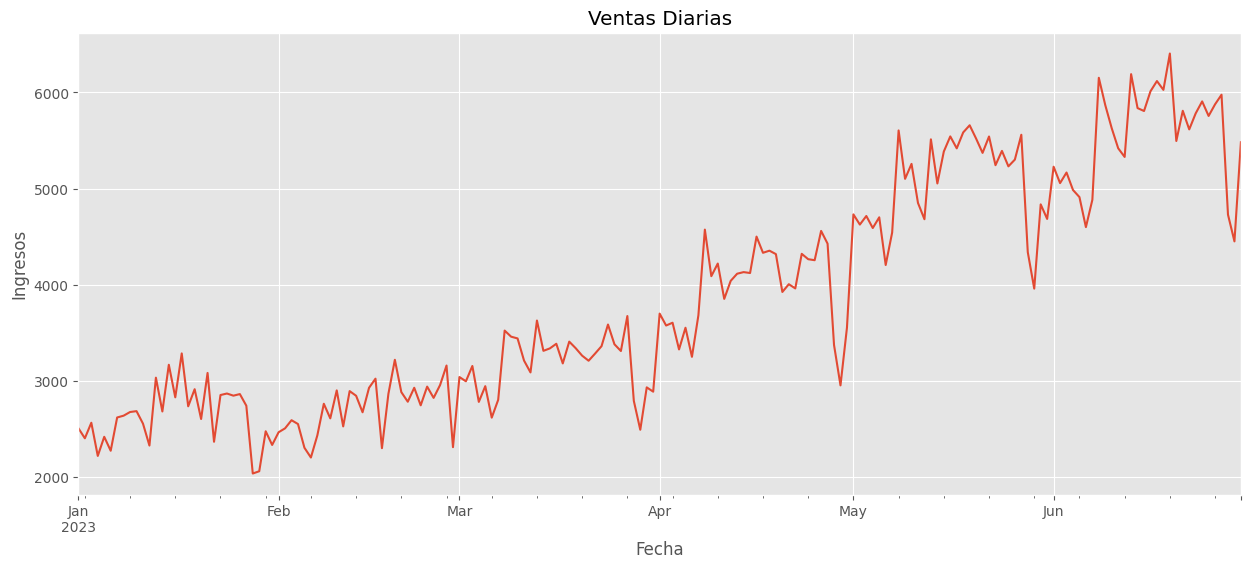

In [17]:
plt.figure(figsize=(15,6))

ventas_dia.plot()

plt.title("Ventas Diarias")
plt.xlabel("Fecha")
plt.ylabel("Ingresos")

plt.show()

In [18]:
clientes_rentables = (
    df.groupby("cliente")["ingresos"]
      .sum()
      .sort_values(ascending=False)
)

clientes_rentables

,ingresos
cliente,
Cliente_11,35929.29
Cliente_16,35746.76
Cliente_13,35520.59
Cliente_02,35407.47
Cliente_08,35132.32
Cliente_19,35100.48
Cliente_17,35093.23
Cliente_10,35066.17
Cliente_09,34985.85


In [19]:
clientes_rentables.head(10)

,ingresos
cliente,
Cliente_11,35929.29
Cliente_16,35746.76
Cliente_13,35520.59
Cliente_02,35407.47
Cliente_08,35132.32
Cliente_19,35100.48
Cliente_17,35093.23
Cliente_10,35066.17
Cliente_09,34985.85


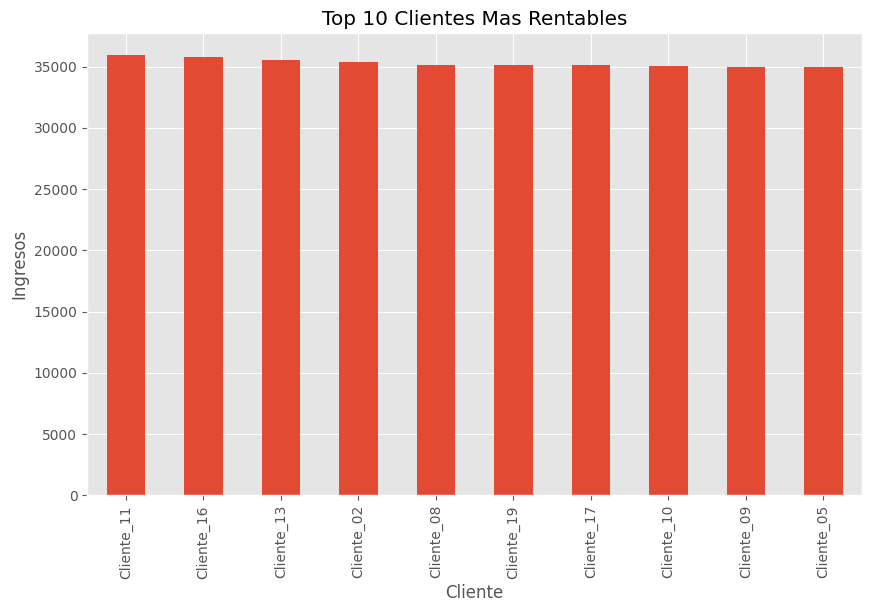

In [24]:
plt.figure(figsize=(10,6))

clientes_rentables.head(10).plot(
    kind="bar"
)

plt.title("Top 10 Clientes Mas Rentables")
plt.xlabel("Cliente")
plt.ylabel("Ingresos")

plt.show()

In [21]:
ventas_categoria = (
    df.groupby("product_category")["ingresos"]
      .sum()
      .sort_values(ascending=False)
)

ventas_categoria

,ingresos
product_category,
Coffee,269952.45
Tea,196405.95
Bakery,82315.64
Drinking Chocolate,72416.00
Coffee beans,40085.25
Branded,13607.00
Loose Tea,11213.60
Flavours,8408.80
Packaged Chocolate,4407.64


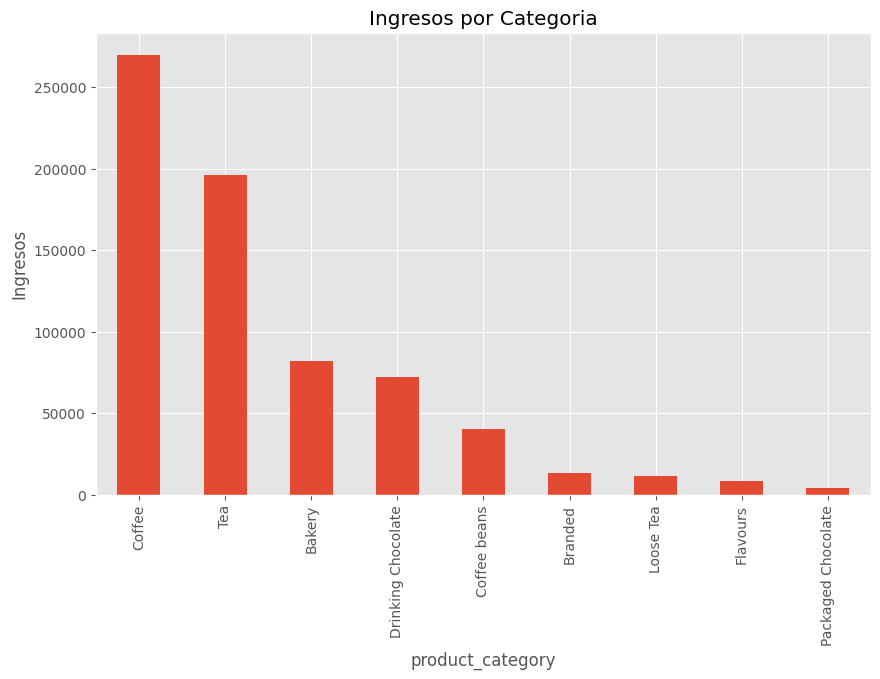

In [25]:
plt.figure(figsize=(10,6))

ventas_categoria.plot(
    kind="bar"
)

plt.title("Ingresos por Categoria")
plt.ylabel("Ingresos")

plt.show()